# 01 — Build the global 0.5° grid

Creates the base `(lat, lon)` grid used by every variable notebook and stores a Natural Earth land mask so downstream notebooks can skip ocean cells.

In [6]:
import numpy as np
import xarray as xr
import regionmask

from common import PROCESSED_DIR

## Mesh

Cell centers at 0.5° spacing: 720 lon × 719 lat = 517 680 cells globally. Each cell is around 50km^2

In [7]:
RES = 0.5
lon = np.arange(-180 + RES / 2, 180, RES)
lat = np.arange(-90 + RES / 2, 90, RES)
print(f'{lon.size} lon × {lat.size} lat = {lon.size * lat.size:,} cells')

720 lon × 360 lat = 259,200 cells


## Land mask

Natural Earth 110m land polygons via `regionmask`. Result is `1` for land cells, `0` for ocean.

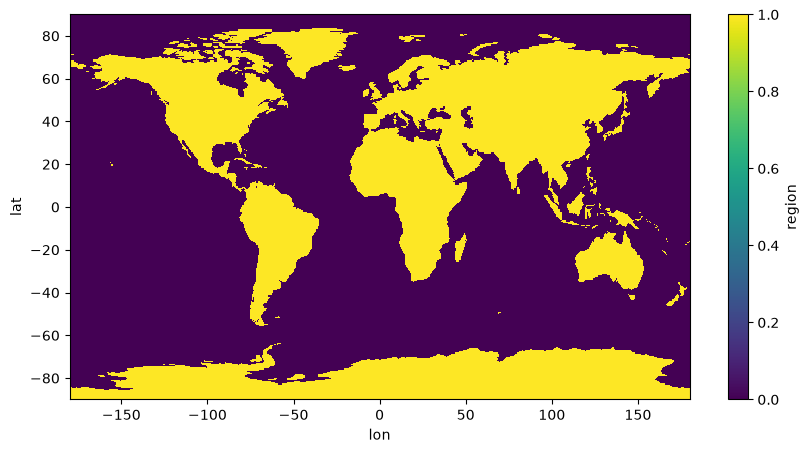

In [8]:
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
mask = land.mask(lon, lat)  # 0 where land, NaN elsewhere
is_land = (~mask.isnull()).astype('int8')
is_land.plot(figsize=(10, 5))

## Save

In [ ]:
from pathlib import Path

grid = xr.Dataset(
    {'is_land': is_land},
    attrs={'resolution_deg': RES, 'source': 'Natural Earth 110m via regionmask'},
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out = PROCESSED_DIR / 'grid.nc'

if Path(out).exists():
    Path(out).unlink()
    
grid.to_netcdf(out)
print(f'wrote {out}')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/grid.nc'